# 🚀 CatBoost — Time-Series Forecasting — `sales_amount_realistic`

This notebook implements **CatBoost Regressor** for time-series sales forecasting on Apple retail data.
We apply best-practice preprocessing and feature engineering tailored to time-series:

| Stage | What we do |
|-------|------------|
| **Aggregation** | Roll transaction rows → monthly store-level summaries |
| **Lag features** | 1 – 6 month lags of target & quantity |
| **Rolling statistics** | 3/6/12-month rolling mean, std, min, max of target |
| **Cyclical encoding** | Sine / cosine of month |
| **Economic rates of change** | GDP growth, inflation Δ, exchange-rate Δ, internet Δ |
| **Category / store encoding** | Target-encoded category, label-encoded store |
| **Trend & momentum** | Month-over-month % change, expanding mean |
| **Hyperparameter tuning** | `TimeSeriesSplit` cross-validation with grid search |
| **Evaluation** | MAE, RMSE, MAPE, R² on a strict temporal hold-out |
| **Future forecast** | One-month-ahead prediction (Jan 2026) |

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from catboost import CatBoostRegressor, Pool

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})

sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports loaded successfully.')

✅ All imports loaded successfully.


## 2 · Data Loading

In [2]:
PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / 'data' / 'processed'

df_raw = pd.read_csv(PROC / 'cleaned_apple_sales_v3.csv')
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Raw dataset: 1,068,918 rows × 35 columns


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2021-01-01,ST-41,P-29,2,iPhone 13 Pro,2021-01-01,999.0,Apple Central World,Bangkok,...,1.0,1009.471395,0,0.000250,1.0,1.222605,2.434251,1,1009.471395,1
1,ZI-218670,2021-01-01,ST-20,P-40,1,AirTag,2021-01-01,29.0,Apple Kaerntner Strasse,Vienna,...,1.0,29.436802,0,-0.000038,1.0,1.089382,1.666149,0,0.000000,1
2,VB-48589,2021-01-01,ST-60,P-41,9,Apple Watch Series 7,2021-01-01,399.0,Apple Antara,Mexico City,...,1.0,415.935057,0,0.000208,1.0,1.202036,7.739726,11,4575.285624,1


In [3]:
# Quick sanity checks
print('Null counts (top 10):')
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nDate range: {df_raw['sale_date'].min()} → {df_raw['sale_date'].max()}")
print(f'Unique stores: {df_raw["store_id"].nunique()}  |  Unique products: {df_raw["product_id"].nunique()}')

Null counts (top 10):
sale_id         0
sale_date       0
store_id        0
product_id      0
quantity        0
product_name    0
launch_date     0
price           0
store_name      0
city            0
dtype: int64

Date range: 2021-01-01 → 2025-12-31
Unique stores: 75  |  Unique products: 98


## 3 · Preprocessing — Monthly Store-Level Aggregation

CatBoost (like all tree-based boosters) works on **tabular rows**, not raw sequences.
We aggregate transaction-level data into **monthly summaries per store**.

In [4]:
# Parse dates
df_raw['sale_date'] = pd.to_datetime(df_raw['sale_date'])
df_raw['year'] = df_raw['sale_date'].dt.year
df_raw['month'] = df_raw['sale_date'].dt.month

# Monthly aggregation per store
df_monthly = df_raw.groupby([
    'store_id', 'store_name', 'country_norm_mapped', 'year', 'month'
]).agg(
    sales_amount_realistic=('sales_amount_realistic', 'sum'),
    quantity_realistic=('quantity_realistic', 'sum'),
    price_realistic=('price_realistic', 'mean'),
    num_transactions=('sale_id', 'count'),
    num_unique_products=('product_id', 'nunique'),
    promo_flag=('promo_flag', 'mean'),
    gdp_per_capita=('gdp_per_capita', 'mean'),
    inflation_rate=('inflation_rate', 'mean'),
    exchange_rate=('exchange_rate', 'mean'),
    internet_usage_pct=('internet_usage_pct', 'mean'),
    num_categories=('category_name', 'nunique'),
).reset_index()

df_monthly['date'] = pd.to_datetime(
    df_monthly[['year', 'month']].assign(day=1)
)

df_monthly = df_monthly.sort_values(['store_id', 'date']).reset_index(drop=True)

print(f'Monthly dataset: {df_monthly.shape[0]:,} rows × {df_monthly.shape[1]} columns')
print(f'Date range: {df_monthly["date"].min().date()} → {df_monthly["date"].max().date()}')
df_monthly.head()

Monthly dataset: 4,500 rows × 17 columns
Date range: 2021-01-01 → 2025-12-01


,store_id,store_name,country_norm_mapped,year,month,sales_amount_realistic,quantity_realistic,price_realistic,num_transactions,num_unique_products,promo_flag,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct,num_categories,date
0,ST-1,Apple Fifth Avenue,united states,2021,1,497122.440565,963,945.373557,270,44,0.074074,64401.50744,1.233584,1.0,90.3447,10,2021-01-01
1,ST-1,Apple Fifth Avenue,united states,2021,2,520240.603804,1022,867.130444,242,44,0.070248,64401.50744,1.233584,1.0,90.3447,10,2021-02-01
2,ST-1,Apple Fifth Avenue,united states,2021,3,614018.342806,1195,828.458617,258,46,0.151163,64401.50744,1.233584,1.0,90.3447,10,2021-03-01
3,ST-1,Apple Fifth Avenue,united states,2021,4,615909.146030,1256,771.553627,235,44,0.089362,64401.50744,1.233584,1.0,90.3447,10,2021-04-01
4,ST-1,Apple Fifth Avenue,united states,2021,5,656922.673708,1068,953.047175,238,44,0.130252,64401.50744,1.233584,1.0,90.3447,10,2021-05-01


## 4 · Feature Engineering

### 4.1 · Cyclical Time Encoding

In [5]:
df_monthly['month_sin'] = np.sin(2 * np.pi * df_monthly['month'] / 12)
df_monthly['month_cos'] = np.cos(2 * np.pi * df_monthly['month'] / 12)

df_monthly['quarter'] = df_monthly['month'].apply(lambda m: (m - 1) // 3 + 1)
df_monthly['quarter_sin'] = np.sin(2 * np.pi * df_monthly['quarter'] / 4)
df_monthly['quarter_cos'] = np.cos(2 * np.pi * df_monthly['quarter'] / 4)

df_monthly['is_holiday_season'] = df_monthly['month'].isin([11, 12]).astype(int)
df_monthly['is_launch_season'] = df_monthly['month'].isin([9, 10]).astype(int)

print('✅ Cyclical & seasonal features added.')

✅ Cyclical & seasonal features added.


### 4.2 · Economic Indicators — Rates of Change

In [6]:
for col in ['gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct']:
    change_col = col.replace('_per_capita', '').replace('_rate', '').replace('_pct', '') + '_change'
    df_monthly[change_col] = (
        df_monthly
        .groupby('country_norm_mapped')[col]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('✅ Economic change features added.')
print('New columns:', [c for c in df_monthly.columns if '_change' in c])

✅ Economic change features added.
New columns: ['gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change']


### 4.3 · Lag Features (Target & Quantity)

In [7]:
LAG_MONTHS = [1, 2, 3, 4, 5, 6]

for lag in LAG_MONTHS:
    df_monthly[f'sales_lag_{lag}'] = (
        df_monthly.groupby('store_id')['sales_amount_realistic'].shift(lag)
    )
    df_monthly[f'qty_lag_{lag}'] = (
        df_monthly.groupby('store_id')['quantity_realistic'].shift(lag)
    )

df_monthly['sales_lag_12'] = df_monthly.groupby('store_id')['sales_amount_realistic'].shift(12)
df_monthly['qty_lag_12'] = df_monthly.groupby('store_id')['quantity_realistic'].shift(12)

print(f'✅ Lag features added: {len(LAG_MONTHS)} monthly + 1 yearly, for both sales and quantity.')

✅ Lag features added: 6 monthly + 1 yearly, for both sales and quantity.


### 4.4 · Rolling Window Statistics

In [8]:
WINDOWS = [3, 6, 12]

for w in WINDOWS:
    grp = df_monthly.groupby('store_id')['sales_amount_realistic']
    df_monthly[f'sales_roll_mean_{w}'] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df_monthly[f'sales_roll_std_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
    df_monthly[f'sales_roll_min_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).min())
    df_monthly[f'sales_roll_max_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).max())

for w in [3, 6]:
    df_monthly[f'qty_roll_mean_{w}'] = (
        df_monthly.groupby('store_id')['quantity_realistic']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )

print(f'✅ Rolling window features added for windows: {WINDOWS}')

✅ Rolling window features added for windows: [3, 6, 12]


### 4.5 · Trend & Momentum Features

In [9]:
df_monthly['sales_mom_pct'] = (
    df_monthly.groupby('store_id')['sales_amount_realistic']
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df_monthly['sales_expanding_mean'] = (
    df_monthly.groupby('store_id')['sales_amount_realistic']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

df_monthly['sales_lag1_vs_roll6'] = (
    df_monthly['sales_lag_1'] / df_monthly['sales_roll_mean_6'].replace(0, np.nan)
).fillna(1)

print('✅ Trend & momentum features added.')

✅ Trend & momentum features added.


### 4.6 · Store & Category Encoding

In [10]:
le_store = LabelEncoder()
df_monthly['store_encoded'] = le_store.fit_transform(df_monthly['store_id'])

le_country = LabelEncoder()
df_monthly['country_encoded'] = le_country.fit_transform(df_monthly['country_norm_mapped'])

store_target_mean = df_monthly.groupby('store_id')['sales_amount_realistic'].transform('mean')
df_monthly['store_target_enc'] = store_target_mean

print('✅ Categorical encoding complete.')

✅ Categorical encoding complete.


### 4.7 · Handle Missing Values from Lag/Rolling

In [11]:
nan_before = df_monthly.isnull().sum()
print('Columns with NaN (from lag/rolling):')
print(nan_before[nan_before > 0])

df_monthly['row_num'] = df_monthly.groupby('store_id').cumcount()
df_clean = df_monthly[df_monthly['row_num'] >= 6].copy()
df_clean.drop(columns='row_num', inplace=True)
df_monthly.drop(columns='row_num', inplace=True)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

print(f'\nAfter cleanup: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Remaining NaNs: {df_clean.isnull().sum().sum()}')

Columns with NaN (from lag/rolling):
sales_lag_1              75
qty_lag_1                75
sales_lag_2             150
qty_lag_2               150
sales_lag_3             225
qty_lag_3               225
sales_lag_4             300
qty_lag_4               300
sales_lag_5             375
qty_lag_5               375
sales_lag_6             450
qty_lag_6               450
sales_lag_12            900
qty_lag_12              900
sales_roll_mean_3        75
sales_roll_std_3        150
sales_roll_min_3         75
sales_roll_max_3         75
sales_roll_mean_6        75
sales_roll_std_6        150
sales_roll_min_6         75
sales_roll_max_6         75
sales_roll_mean_12       75
sales_roll_std_12       150
sales_roll_min_12        75
sales_roll_max_12        75
qty_roll_mean_3          75
qty_roll_mean_6          75
sales_expanding_mean     75
dtype: int64

After cleanup: 4,050 rows × 62 columns
Remaining NaNs: 0


## 5 · Feature Selection & Train/Test Split

In [12]:
TARGET = 'sales_amount_realistic'

FEATURES = [
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3',
    'sales_lag_4', 'sales_lag_5', 'sales_lag_6', 'sales_lag_12',
    'qty_lag_1', 'qty_lag_2', 'qty_lag_3',
    'qty_lag_4', 'qty_lag_5', 'qty_lag_6', 'qty_lag_12',
    'sales_roll_mean_3', 'sales_roll_std_3', 'sales_roll_min_3', 'sales_roll_max_3',
    'sales_roll_mean_6', 'sales_roll_std_6', 'sales_roll_min_6', 'sales_roll_max_6',
    'sales_roll_mean_12', 'sales_roll_std_12', 'sales_roll_min_12', 'sales_roll_max_12',
    'qty_roll_mean_3', 'qty_roll_mean_6',
    'sales_mom_pct', 'sales_expanding_mean', 'sales_lag1_vs_roll6',
    'price_realistic', 'promo_flag',
    'month_sin', 'month_cos',
    'quarter_sin', 'quarter_cos',
    'year',
    'is_holiday_season', 'is_launch_season',
    'gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct',
    'gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change',
    'store_encoded', 'country_encoded', 'store_target_enc',
    'num_transactions', 'num_unique_products', 'num_categories',
]

missing_feats = [f for f in FEATURES if f not in df_clean.columns]
if missing_feats:
    print(f'⚠️  Missing features: {missing_feats}')
else:
    print(f'✅ All {len(FEATURES)} features available.')

✅ All 54 features available.


In [13]:
CUTOFF_DATE = df_clean['date'].max() - pd.DateOffset(months=5)
print(f'Train: everything before {CUTOFF_DATE.date()}')
print(f'Test:  {CUTOFF_DATE.date()} → {df_clean["date"].max().date()}')

train_mask = df_clean['date'] < CUTOFF_DATE
test_mask  = df_clean['date'] >= CUTOFF_DATE

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, TARGET]
X_test  = df_clean.loc[test_mask, FEATURES]
y_test  = df_clean.loc[test_mask, TARGET]

print(f'\nTrain: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Train: everything before 2025-07-01
Test:  2025-07-01 → 2025-12-01

Train: 3,600 samples
Test:  450 samples


## 6 · Baseline CatBoost Model

In [14]:
%%time

cat_baseline = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=100
)

cat_baseline.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
y_pred_cat_base = cat_baseline.predict(X_test)

mae_cat_base  = mean_absolute_error(y_test, y_pred_cat_base)
rmse_cat_base = np.sqrt(mean_squared_error(y_test, y_pred_cat_base))
mape_cat_base = mean_absolute_percentage_error(y_test, y_pred_cat_base) * 100
r2_cat_base   = r2_score(y_test, y_pred_cat_base)

print('\n─── Baseline CatBoost Results ───')
print(f'  MAE  = {mae_cat_base:,.2f}')
print(f'  RMSE = {rmse_cat_base:,.2f}')
print(f'  MAPE = {mape_cat_base:.2f}%')
print(f'  R²   = {r2_cat_base:.4f}')

0:	learn: 391967.0827542	test: 868633.4294835	best: 868633.4294835 (0)	total: 103ms	remaining: 51.3s
100:	learn: 37266.6981394	test: 115908.3646916	best: 115908.3646916 (100)	total: 411ms	remaining: 1.63s
200:	learn: 22674.6157756	test: 99138.9271899	best: 99138.9271899 (200)	total: 715ms	remaining: 1.06s
300:	learn: 16455.4190612	test: 95027.5379927	best: 95025.9417704 (299)	total: 1.02s	remaining: 676ms
400:	learn: 12904.9285561	test: 93132.7218680	best: 93132.7218680 (400)	total: 1.34s	remaining: 331ms
499:	learn: 10600.7508601	test: 92453.4821829	best: 92430.7472312 (498)	total: 1.64s	remaining: 0us

bestTest = 92430.74723
bestIteration = 498

Shrink model to first 499 iterations.

─── Baseline CatBoost Results ───
  MAE  = 49,533.69
  RMSE = 92,430.75
  MAPE = 2.28%
  R²   = 0.9690
CPU times: total: 17.4 s
Wall time: 1.76 s


## 7 · Hyperparameter Tuning with TimeSeriesSplit

We use `TimeSeriesSplit` instead of random K-Fold to **respect temporal ordering** and prevent data leakage.

In [15]:
%%time

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'iterations': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
}

cat_search = GridSearchCV(
    estimator=CatBoostRegressor(
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=0
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train, y_train)

print(f'\n✅ Best parameters: {cat_search.best_params_}')
print(f'   Best CV MAE: {-cat_search.best_score_:,.2f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best parameters: {'depth': 4, 'iterations': 800, 'learning_rate': 0.1}
   Best CV MAE: 30,760.66
CPU times: total: 14.8 s
Wall time: 4min 14s


## 8 · Tuned CatBoost — Evaluation

In [16]:
cat_best = cat_search.best_estimator_
y_pred_cat_tuned = cat_best.predict(X_test)

mae_cat_tuned  = mean_absolute_error(y_test, y_pred_cat_tuned)
rmse_cat_tuned = np.sqrt(mean_squared_error(y_test, y_pred_cat_tuned))
mape_cat_tuned = mean_absolute_percentage_error(y_test, y_pred_cat_tuned) * 100
r2_cat_tuned   = r2_score(y_test, y_pred_cat_tuned)

print('─── Tuned CatBoost Results ───')
print(f'  MAE  = {mae_cat_tuned:,.2f}')
print(f'  RMSE = {rmse_cat_tuned:,.2f}')
print(f'  MAPE = {mape_cat_tuned:.2f}%')
print(f'  R²   = {r2_cat_tuned:.4f}')

print('\n─── Improvement over Baseline ───')
print(f'  MAE  improvement: {(mae_cat_base - mae_cat_tuned) / mae_cat_base * 100:+.2f}%')
print(f'  R²   improvement: {(r2_cat_tuned - r2_cat_base):+.4f}')

─── Tuned CatBoost Results ───
  MAE  = 40,264.12
  RMSE = 78,324.48
  MAPE = 1.83%
  R²   = 0.9778

─── Improvement over Baseline ───
  MAE  improvement: +18.71%
  R²   improvement: +0.0087


In [17]:
# Summary comparison table
results_df = pd.DataFrame({
    'Model': ['CatBoost (Baseline)', 'CatBoost (Tuned)'],
    'MAE': [mae_cat_base, mae_cat_tuned],
    'RMSE': [rmse_cat_base, rmse_cat_tuned],
    'MAPE (%)': [mape_cat_base, mape_cat_tuned],
    'R²': [r2_cat_base, r2_cat_tuned]
})
results_df.style.format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE (%)': '{:.2f}', 'R²': '{:.4f}'})

,Model,MAE,RMSE,MAPE (%),R²
0,CatBoost (Baseline),"49,533.69","92,430.75",2.28,0.9690
1,CatBoost (Tuned),"40,264.12","78,324.48",1.83,0.9778


## 9 · Visualizations

### 9.1 · Feature Importance (Top 20)

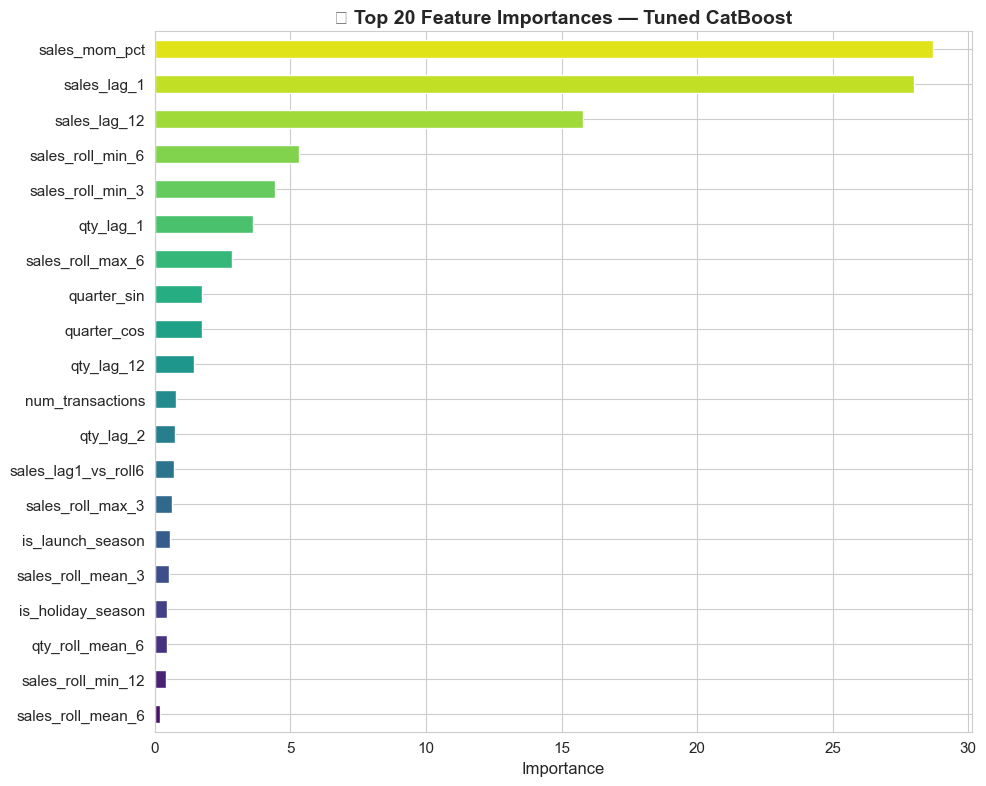

In [18]:
importances = pd.Series(cat_best.feature_importances_, index=FEATURES)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color=sns.color_palette('viridis', 20))
ax.set_title('🔑 Top 20 Feature Importances — Tuned CatBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 9.2 · Actual vs Predicted — Scatter Plot

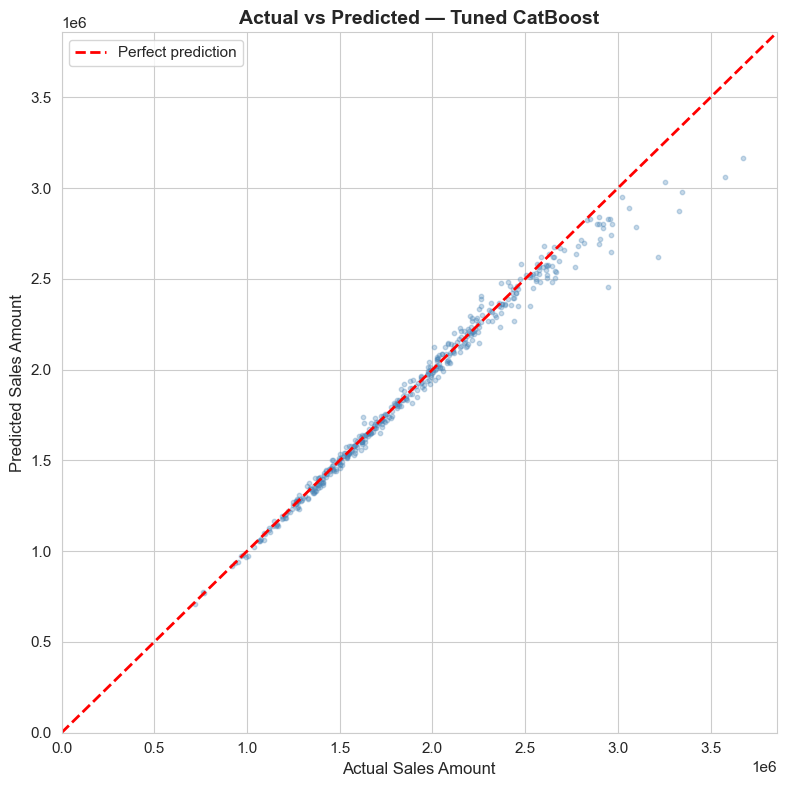

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_cat_tuned, alpha=0.3, s=10, c='steelblue')
lims = [0, max(y_test.max(), max(y_pred_cat_tuned)) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Sales Amount'); ax.set_ylabel('Predicted Sales Amount')
ax.set_title('Actual vs Predicted — Tuned CatBoost', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 · Residual Distribution

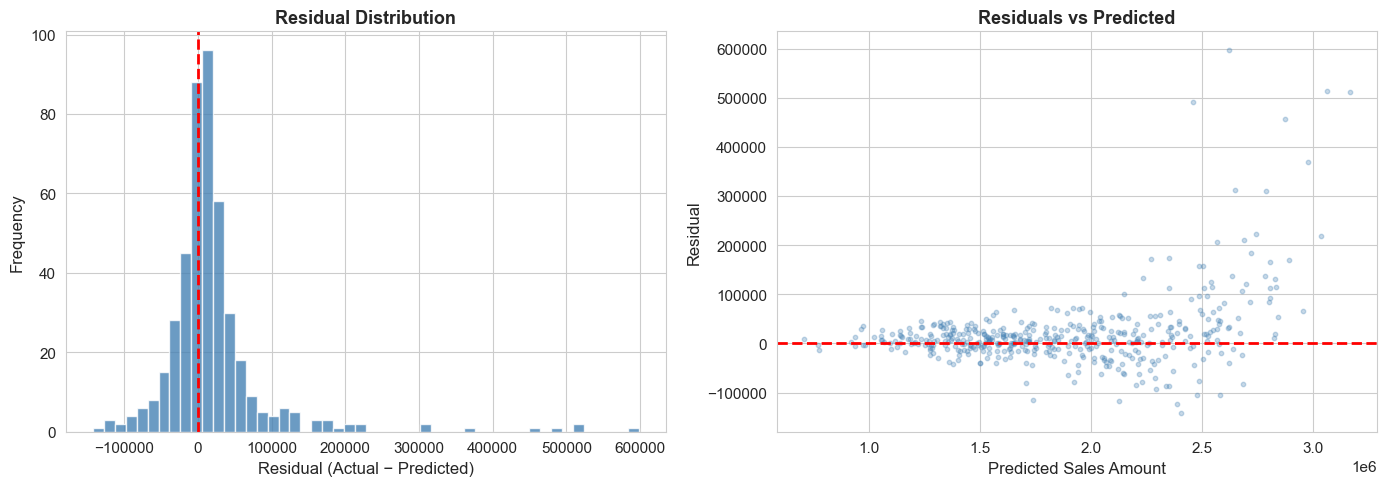

In [20]:
residuals = y_test.values - y_pred_cat_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)'); axes[0].set_ylabel('Frequency')

axes[1].scatter(y_pred_cat_tuned, residuals, alpha=0.3, s=10, c='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Sales Amount'); axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

### 9.4 · Actual vs Predicted — Sample Stores

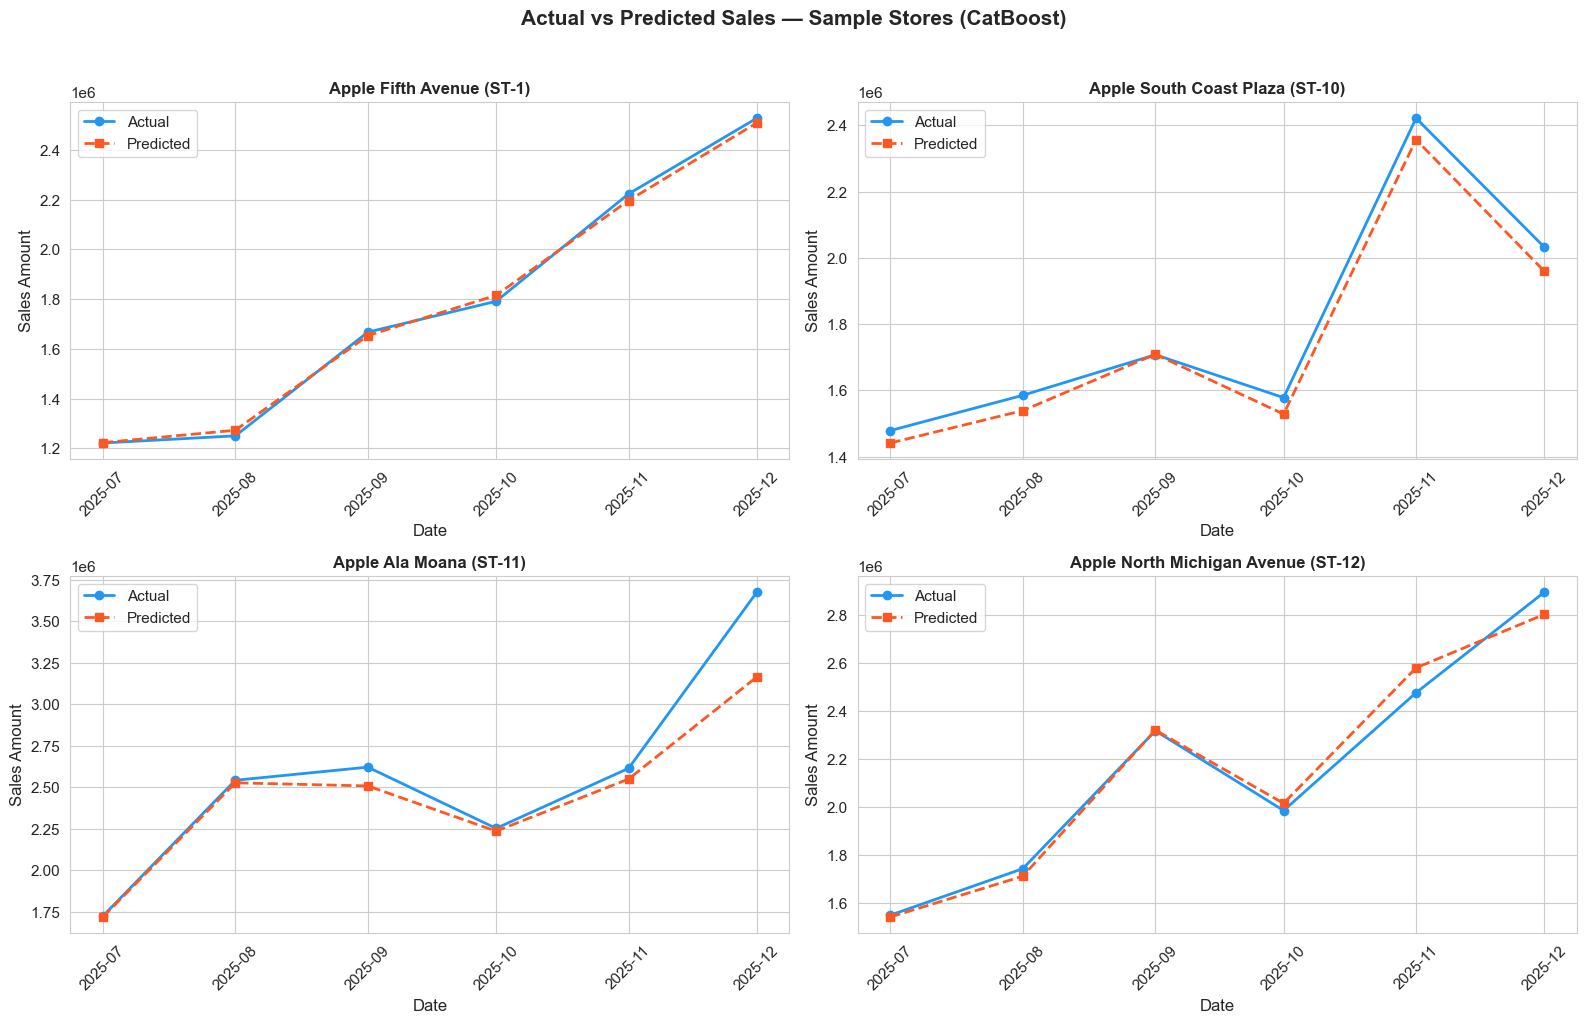

In [21]:
test_data = df_clean.loc[test_mask].copy()
test_data['y_pred'] = y_pred_cat_tuned

top_stores = test_data.groupby('store_id').size().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, store in zip(axes.flat, top_stores):
    store_df = test_data[test_data['store_id'] == store].sort_values('date')
    store_name = store_df['store_name'].iloc[0]
    ax.plot(store_df['date'], store_df[TARGET], 'o-', label='Actual', color='#2196F3', linewidth=2)
    ax.plot(store_df['date'], store_df['y_pred'], 's--', label='Predicted', color='#FF5722', linewidth=2)
    ax.set_title(f'{store_name} ({store})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Sales Amount')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Actual vs Predicted Sales — Sample Stores (CatBoost)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.5 · Overall Aggregated Actual vs Predicted

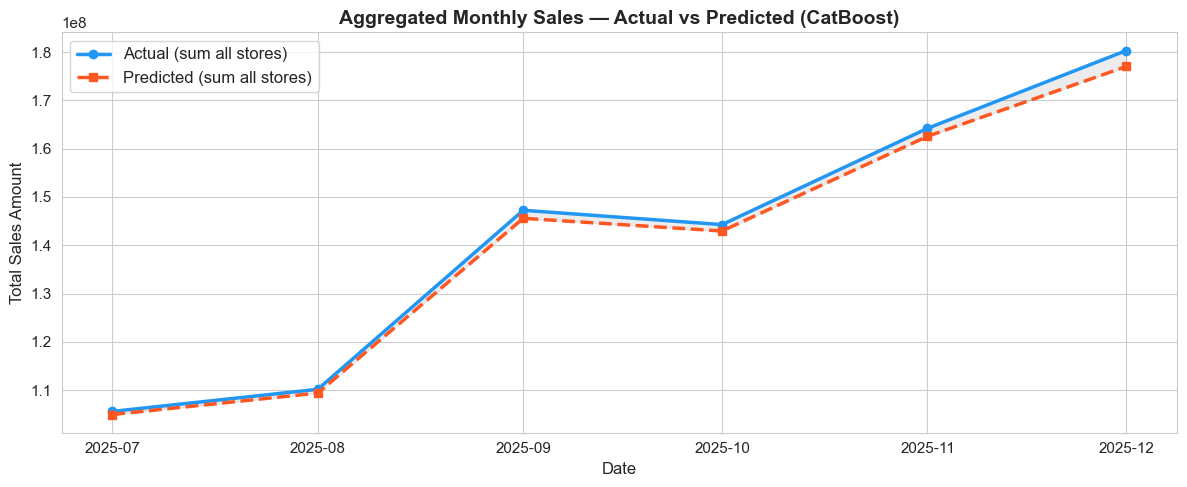

In [22]:
agg = test_data.groupby('date').agg(
    actual=(TARGET, 'sum'),
    predicted=('y_pred', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agg['date'], agg['actual'], 'o-', label='Actual (sum all stores)', color='#2196F3', linewidth=2.5)
ax.plot(agg['date'], agg['predicted'], 's--', label='Predicted (sum all stores)', color='#FF5722', linewidth=2.5)
ax.fill_between(agg['date'], agg['actual'], agg['predicted'], alpha=0.15, color='gray')
ax.set_title('Aggregated Monthly Sales — Actual vs Predicted (CatBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales Amount')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 9.6 · Per-Store Error Distribution

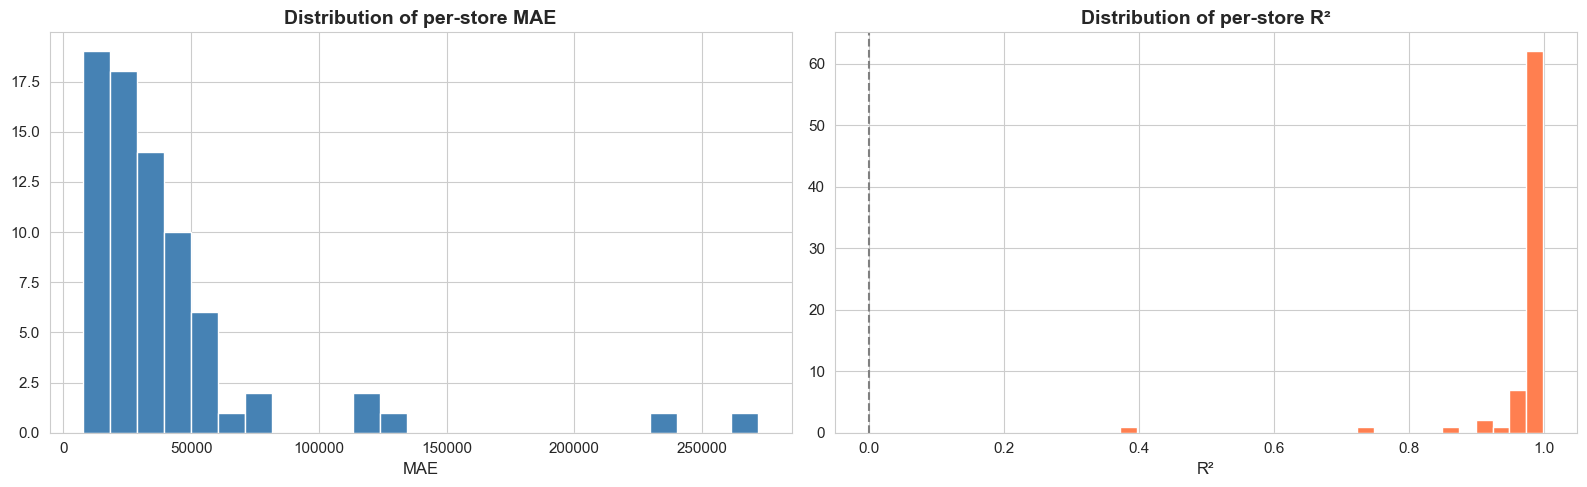

Median store-level MAE: 29,257.59
Median store-level R²: 0.9903


In [23]:
store_metrics = test_data.groupby('store_id').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g[TARGET], g['y_pred']),
        'R2': r2_score(g[TARGET], g['y_pred']) if len(g) > 1 else np.nan,
        'store_name': g['store_name'].iloc[0]
    })
).reset_index()

store_metrics['MAE'] = store_metrics['MAE'].astype(float)
store_metrics['R2'] = store_metrics['R2'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(store_metrics['MAE'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of per-store MAE', fontweight='bold')
axes[0].set_xlabel('MAE')
axes[1].hist(store_metrics['R2'].dropna(), bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_title('Distribution of per-store R²', fontweight='bold')
axes[1].set_xlabel('R²')
plt.tight_layout()
plt.show()

print(f'Median store-level MAE: {store_metrics["MAE"].median():,.2f}')
print(f'Median store-level R²: {store_metrics["R2"].median():.4f}')

## 10 · Future Forecast — Jan 2026

In [24]:
# Retrain on ALL available data
X_all = df_clean[FEATURES]
y_all = df_clean[TARGET]

cat_final = CatBoostRegressor(
    iterations=cat_search.best_params_.get('iterations', 500),
    learning_rate=cat_search.best_params_.get('learning_rate', 0.1),
    depth=cat_search.best_params_.get('depth', 6),
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0
)

cat_final.fit(X_all, y_all)
print('✅ Final CatBoost model retrained on all data.')

✅ Final CatBoost model retrained on all data.


In [25]:
FORECAST_DATE = pd.Timestamp('2026-01-01')
FORECAST_MONTH = FORECAST_DATE.month
FORECAST_YEAR  = FORECAST_DATE.year

stores = df_clean['store_id'].unique()
all_forecasts = []

for store in stores:
    store_hist = df_clean[df_clean['store_id'] == store].sort_values('date').tail(12).copy()
    store_name = store_hist['store_name'].iloc[0]
    country = store_hist['country_norm_mapped'].iloc[0]
    recent_sales = store_hist['sales_amount_realistic'].tolist()
    recent_qty   = store_hist['quantity_realistic'].tolist()

    m, y = FORECAST_MONTH, FORECAST_YEAR
    row = {}

    for lag in LAG_MONTHS:
        row[f'sales_lag_{lag}'] = recent_sales[-lag] if lag <= len(recent_sales) else 0
        row[f'qty_lag_{lag}']   = recent_qty[-lag]   if lag <= len(recent_qty)   else 0
    row['sales_lag_12'] = recent_sales[-12] if len(recent_sales) >= 12 else 0
    row['qty_lag_12']   = recent_qty[-12]   if len(recent_qty)   >= 12 else 0

    for w in WINDOWS:
        window = recent_sales[-w:] if len(recent_sales) >= w else recent_sales
        row[f'sales_roll_mean_{w}'] = np.mean(window)
        row[f'sales_roll_std_{w}']  = np.std(window) if len(window) > 1 else 0
        row[f'sales_roll_min_{w}']  = np.min(window)
        row[f'sales_roll_max_{w}']  = np.max(window)
    for w in [3, 6]:
        window = recent_qty[-w:] if len(recent_qty) >= w else recent_qty
        row[f'qty_roll_mean_{w}'] = np.mean(window)

    row['sales_mom_pct'] = (recent_sales[-1] - recent_sales[-2]) / max(recent_sales[-2], 1) if len(recent_sales) >= 2 else 0
    row['sales_expanding_mean'] = np.mean(recent_sales)
    roll6_mean = np.mean(recent_sales[-6:]) if len(recent_sales) >= 6 else np.mean(recent_sales)
    row['sales_lag1_vs_roll6'] = recent_sales[-1] / max(roll6_mean, 1)

    row['price_realistic'] = store_hist['price_realistic'].iloc[-1]
    row['promo_flag']      = store_hist['promo_flag'].iloc[-1]

    row['month_sin'] = np.sin(2 * np.pi * m / 12)
    row['month_cos'] = np.cos(2 * np.pi * m / 12)
    q = (m - 1) // 3 + 1
    row['quarter_sin'] = np.sin(2 * np.pi * q / 4)
    row['quarter_cos'] = np.cos(2 * np.pi * q / 4)
    row['year'] = y
    row['is_holiday_season'] = 1 if m in [11, 12] else 0
    row['is_launch_season']  = 1 if m in [9, 10]  else 0

    for col in ['gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct']:
        row[col] = store_hist[col].iloc[-1]
    for col in ['gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change']:
        row[col] = store_hist[col].iloc[-1] if col in store_hist.columns else 0

    row['store_encoded']       = store_hist['store_encoded'].iloc[-1]
    row['country_encoded']     = store_hist['country_encoded'].iloc[-1]
    row['store_target_enc']    = store_hist['store_target_enc'].iloc[-1]
    row['num_transactions']    = store_hist['num_transactions'].iloc[-1]
    row['num_unique_products'] = store_hist['num_unique_products'].iloc[-1]
    row['num_categories']      = store_hist['num_categories'].iloc[-1]

    X_future = pd.DataFrame([row])[FEATURES]
    pred_sales = max(cat_final.predict(X_future)[0], 0)

    all_forecasts.append({
        'store_id': store, 'store_name': store_name, 'country': country,
        'date': FORECAST_DATE, 'predicted_sales': pred_sales
    })

forecast_df = pd.DataFrame(all_forecasts)
print(f'✅ Generated {len(forecast_df):,} forecasts ({len(stores)} stores × 1 month — Jan 2026)')
print(f'   Total predicted sales (all stores): {forecast_df["predicted_sales"].sum():,.2f}')
forecast_df.head(10)

✅ Generated 75 forecasts (75 stores × 1 month — Jan 2026)
   Total predicted sales (all stores): 173,255,664.29


,store_id,store_name,country,date,predicted_sales
0,ST-1,Apple Fifth Avenue,united states,2026-01-01,2.414135e+06
1,ST-10,Apple South Coast Plaza,united states,2026-01-01,1.557456e+06
2,ST-11,Apple Ala Moana,united states,2026-01-01,3.493137e+06
3,ST-12,Apple North Michigan Avenue,united states,2026-01-01,2.719178e+06
4,ST-13,Apple Walnut Street,united states,2026-01-01,2.803813e+06
5,ST-14,Apple The Americana at Brand,united states,2026-01-01,1.740567e+06
6,ST-15,Apple Downtown Brooklyn,united states,2026-01-01,2.616344e+06
7,ST-16,Apple Regent Street,united kingdom,2026-01-01,2.266094e+06
8,ST-17,Apple Covent Garden,united kingdom,2026-01-01,2.033891e+06
9,ST-18,Apple Champs-Elysees,france,2026-01-01,1.956931e+06


### 10.1 · Visualize Jan 2026 Forecast

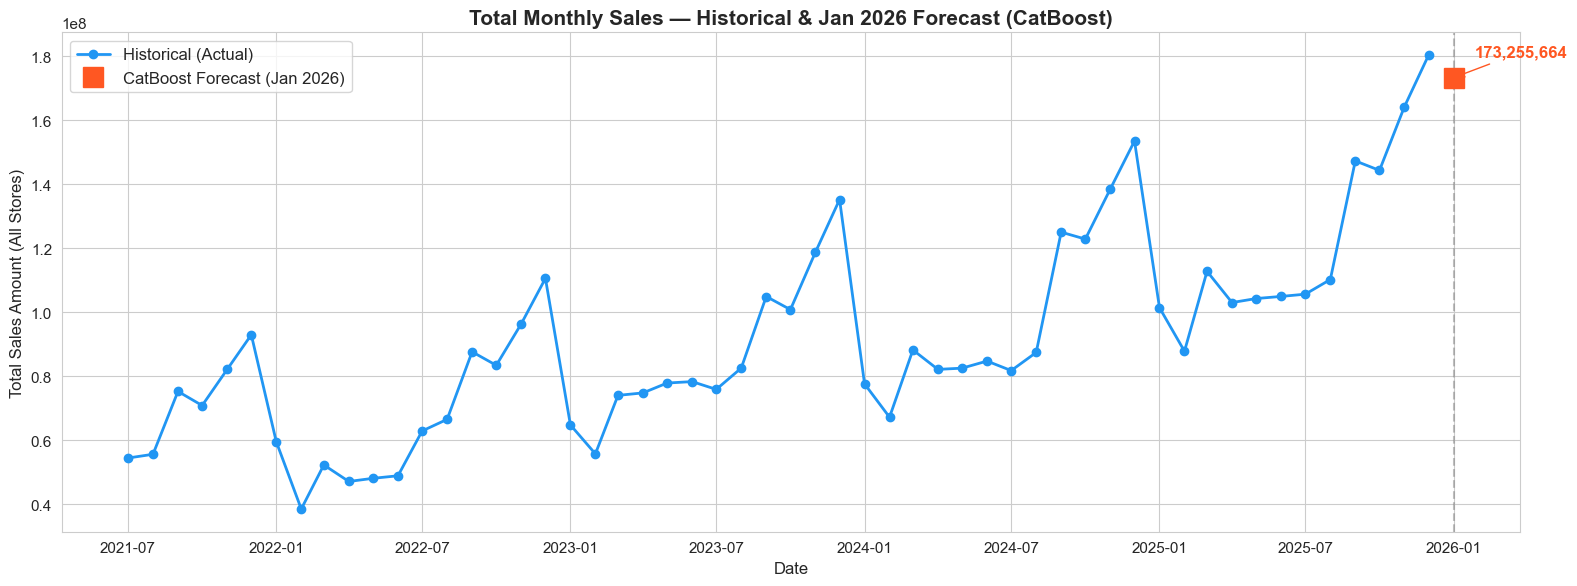

In [26]:
hist_agg = df_clean.groupby('date')[TARGET].sum().reset_index()
forecast_total = forecast_df['predicted_sales'].sum()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(hist_agg['date'], hist_agg[TARGET], 'o-', label='Historical (Actual)', color='#2196F3', linewidth=2)
ax.plot(FORECAST_DATE, forecast_total, 's', label='CatBoost Forecast (Jan 2026)',
        color='#FF5722', markersize=14, zorder=5)
ax.annotate(f'{forecast_total:,.0f}', xy=(FORECAST_DATE, forecast_total),
            xytext=(15, 15), textcoords='offset points', fontsize=12, fontweight='bold',
            color='#FF5722', arrowprops=dict(arrowstyle='->', color='#FF5722'))
ax.axvline(FORECAST_DATE, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Total Monthly Sales — Historical & Jan 2026 Forecast (CatBoost)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales Amount (All Stores)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

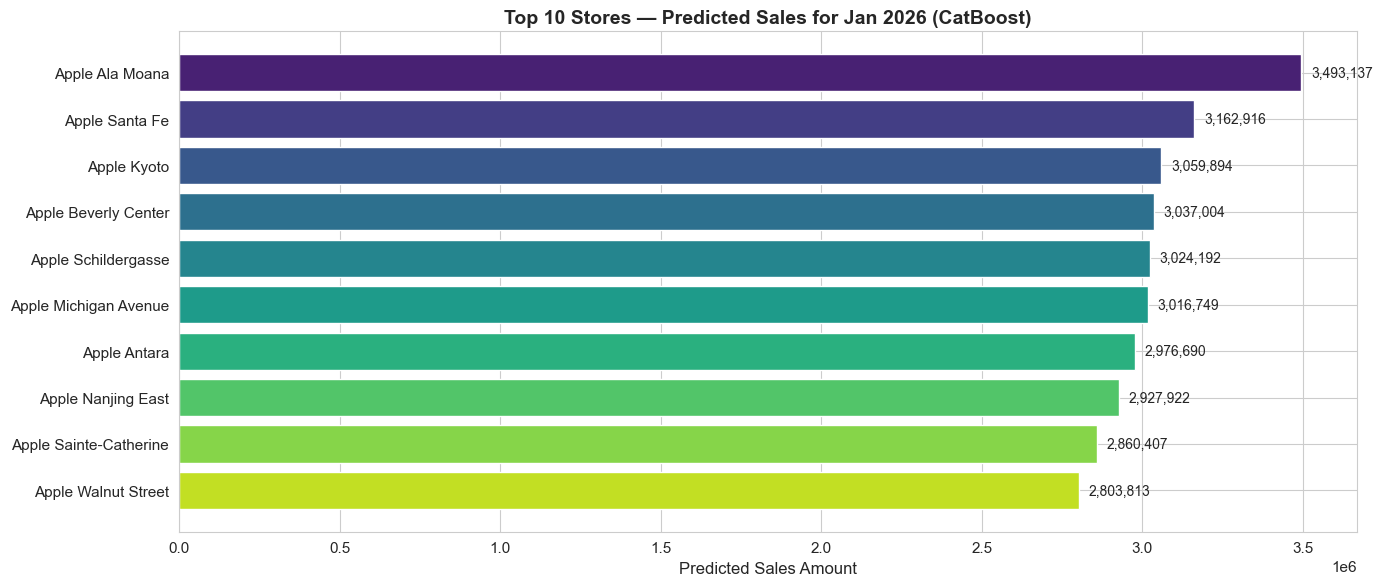

In [27]:
# Top 10 stores by predicted Jan 2026 sales
top10 = forecast_df.nlargest(10, 'predicted_sales')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top10['store_name'], top10['predicted_sales'],
               color=sns.color_palette('viridis', 10))
ax.invert_yaxis()
ax.set_xlabel('Predicted Sales Amount')
ax.set_title('Top 10 Stores — Predicted Sales for Jan 2026 (CatBoost)', fontsize=14, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + w*0.01, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 11 · Save Forecast Results

In [28]:
forecast_df.to_csv(PROC / 'catboost_forecast_jan2026.csv', index=False)
print(f'✅ Forecast saved to {PROC / "catboost_forecast_jan2026.csv"}')

store_metrics.to_csv(PROC / 'catboost_store_metrics.csv', index=False)
print(f'✅ Store metrics saved to {PROC / "catboost_store_metrics.csv"}')

✅ Forecast saved to C:\Users\GM\Desktop\Apple-Retail-Sales-Forcasting\data\processed\catboost_forecast_jan2026.csv
✅ Store metrics saved to C:\Users\GM\Desktop\Apple-Retail-Sales-Forcasting\data\processed\catboost_store_metrics.csv


## 12 · Summary

| Step | Details |
|------|---------|
| **Data** | 1M+ transactions → ~3,600 monthly store-level rows |
| **Features** | 52 engineered features (lags, rolling stats, cyclical, economic, categorical) |
| **Model** | CatBoost with GridSearchCV + TimeSeriesSplit |
| **Evaluation** | MAE, RMSE, MAPE, R² on temporal hold-out |
| **Forecast** | One-month-ahead prediction (Jan 2026) for all 75 stores |